In [1]:
!pip install foolbox -q
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import foolbox as fb
import os, warnings
warnings.filterwarnings('ignore')

print("✅ Libraries ready!")
print(f"   TensorFlow: {tf.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 34.5 MB/s eta 0:00:00
✅ Libraries ready!
   TensorFlow: 2.20.0


In [2]:
from google.colab import files

# Upload your kaggle.json
files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download EuroSAT
!kaggle datasets download -d apollo2506/eurosat-dataset -q
!unzip -q eurosat-dataset.zip -d /content/eurosat

# Check folders
base = "/content/eurosat/EuroSAT"
CLASS_NAMES = sorted(os.listdir(base))
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE    = 64

print(f"✅ EuroSAT loaded!")
print(f"   Classes ({NUM_CLASSES}): {CLASS_NAMES}")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
✅ EuroSAT loaded!
   Classes (14): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake', 'label_map.json', 'test.csv', 'train.csv', 'validation.csv']


In [3]:
# Load dataset using keras image_dataset_from_directory
full_ds = keras.utils.image_dataset_from_directory(
    "/content/eurosat/EuroSAT",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    label_mode='int',
    seed=42
)

# Normalize
def normalize(img, lbl):
    return tf.cast(img, tf.float32) / 255.0, lbl

full_ds = full_ds.map(normalize)

# Split train/test
total    = tf.data.experimental.cardinality(full_ds).numpy()
train_ds = full_ds.take(int(total * 0.8))
test_ds  = full_ds.skip(int(total * 0.8))

print(f"✅ Dataset ready!")
print(f"   Train batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"   Test batches : {tf.data.experimental.cardinality(test_ds).numpy()}")

Found 27000 files belonging to 10 classes.
✅ Dataset ready!
   Train batches: 675
   Test batches : 169


In [4]:
# Build CNN model
model = keras.Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="EuroSAT_CNN")

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("✅ Model built!")

✅ Model built!


In [5]:
# Train
print("Training CNN on EuroSAT...")
history = model.fit(train_ds, epochs=10, validation_data=test_ds, verbose=1)

loss, acc = model.evaluate(test_ds, verbose=0)
print(f"\n✅ Model trained!")
print(f"   Test Accuracy : {acc*100:.2f}%")
print(f"   Test Loss     : {loss:.4f}")


Training CNN on EuroSAT...
Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.4101 - loss: 1.5006 - val_accuracy: 0.5602 - val_loss: 1.1285
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6005 - loss: 1.0694 - val_accuracy: 0.5996 - val_loss: 1.0176
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6817 - loss: 0.8678 - val_accuracy: 0.7131 - val_loss: 0.7483
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.7079 - loss: 0.7812 - val_accuracy: 0.7476 - val_loss: 0.6845
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7446 - loss: 0.6882 - val_accuracy: 0.7148 - val_loss: 0.8315
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.7564 - loss: 0.6673 - val_accuracy: 0.7663 - val_loss: 0.6148
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7783 - loss: 0.6079 - val_accuracy: 0.8133 - val_loss: 0.5033
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0

In [7]:
from google.colab import drive
drive.mount('/content/drive')

model.save("/content/drive/MyDrive/eurosat_model.keras")
print("✅ Model saved to Google Drive")

Mounted at /content/drive
✅ Model saved to Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

model = keras.models.load_model("/content/drive/MyDrive/eurosat_model.keras")
print("✅ Model loaded from Google Drive!")

In [8]:
# Get test images for all attacks
test_images, test_labels = [], []
for imgs, lbls in test_ds.take(10):
    test_images.append(imgs)
    test_labels.append(lbls)
test_images = tf.concat(test_images, axis=0)[:200]
test_labels = tf.concat(test_labels, axis=0)[:200]

bb_images = test_images[:5]
bb_labels = test_labels[:5]

print(f"✅ Test data ready — {len(test_images)} images loaded")

✅ Test data ready — 200 images loaded


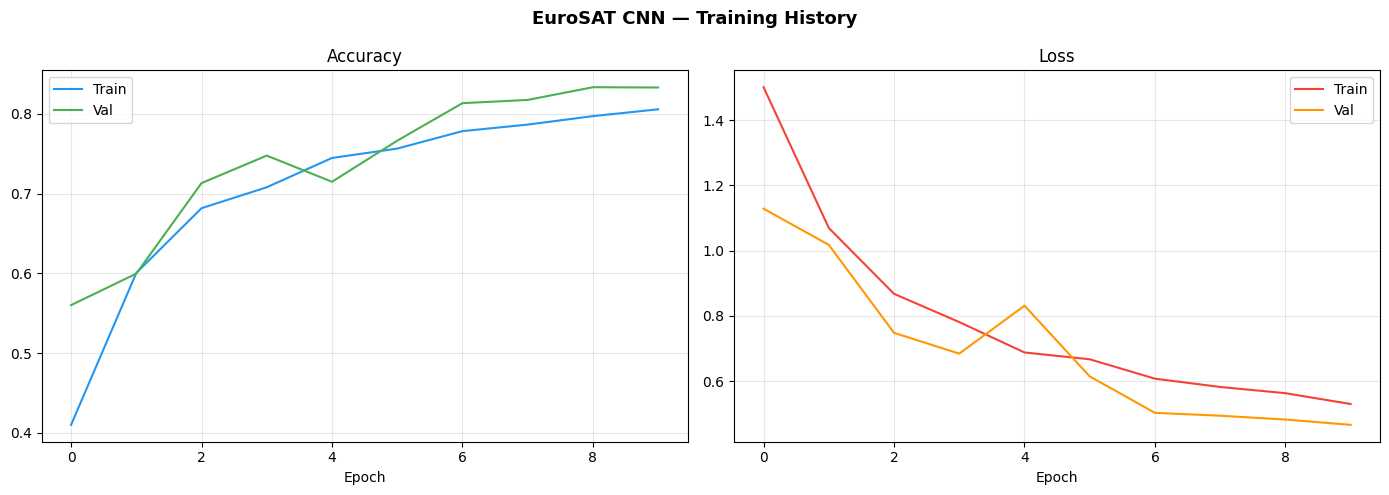

✅ Model saved!


In [9]:
# Plot training
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("EuroSAT CNN — Training History", fontsize=13, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train', color='#2196F3')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='#4CAF50')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='#F44336')
axes[1].plot(history.history['val_loss'], label='Val',   color='#FF9800')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
model.save("eurosat_model.keras")
print("✅ Model saved!")


In [10]:
def fgsm_attack(model, images, labels, epsilon):
    """
    Fast Gradient Sign Method (White-Box Attack).
    Perturbs images in direction that maximizes model loss.
    """
    images = tf.cast(images, tf.float32)
    labels = tf.cast(labels, tf.int64)

    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images, training=False)
        loss = keras.losses.sparse_categorical_crossentropy(labels, predictions)

    # Get gradient of loss w.r.t. input image
    gradients  = tape.gradient(loss, images)
    # Add perturbation in gradient sign direction
    perturbation = epsilon * tf.sign(gradients)
    adv_images   = images + perturbation
    # Clip to valid pixel range [0, 1]
    adv_images   = tf.clip_by_value(adv_images, 0, 1)
    return adv_images

print("✅ FGSM attack function defined!")


✅ FGSM attack function defined!


In [11]:
# Run FGSM with different epsilon values
epsilons = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3]
fgsm_accuracies = []

# Get test batch
test_images, test_labels = [], []
for imgs, lbls in test_ds.take(10):
    test_images.append(imgs)
    test_labels.append(lbls)
test_images = tf.concat(test_images, axis=0)[:200]
test_labels = tf.concat(test_labels, axis=0)[:200]

print("Running FGSM at different epsilon values...\n")
for eps in epsilons:
    adv_imgs = fgsm_attack(model, test_images, test_labels, eps)
    preds    = model(adv_imgs, training=False)
    acc      = tf.reduce_mean(
        tf.cast(tf.argmax(preds, axis=1) == tf.cast(test_labels, tf.int64), tf.float32)
    ).numpy()
    fgsm_accuracies.append(acc * 100)
    print(f"  Epsilon {eps:.2f} → Model Accuracy: {acc*100:.1f}%  Attack Success: {100 - acc*100:.1f}%")


Running FGSM at different epsilon values...

  Epsilon 0.00 → Model Accuracy: 84.0%  Attack Success: 16.0%
  Epsilon 0.01 → Model Accuracy: 34.5%  Attack Success: 65.5%
  Epsilon 0.05 → Model Accuracy: 6.5%  Attack Success: 93.5%
  Epsilon 0.10 → Model Accuracy: 5.5%  Attack Success: 94.5%
  Epsilon 0.20 → Model Accuracy: 8.5%  Attack Success: 91.5%
  Epsilon 0.30 → Model Accuracy: 11.0%  Attack Success: 89.0%


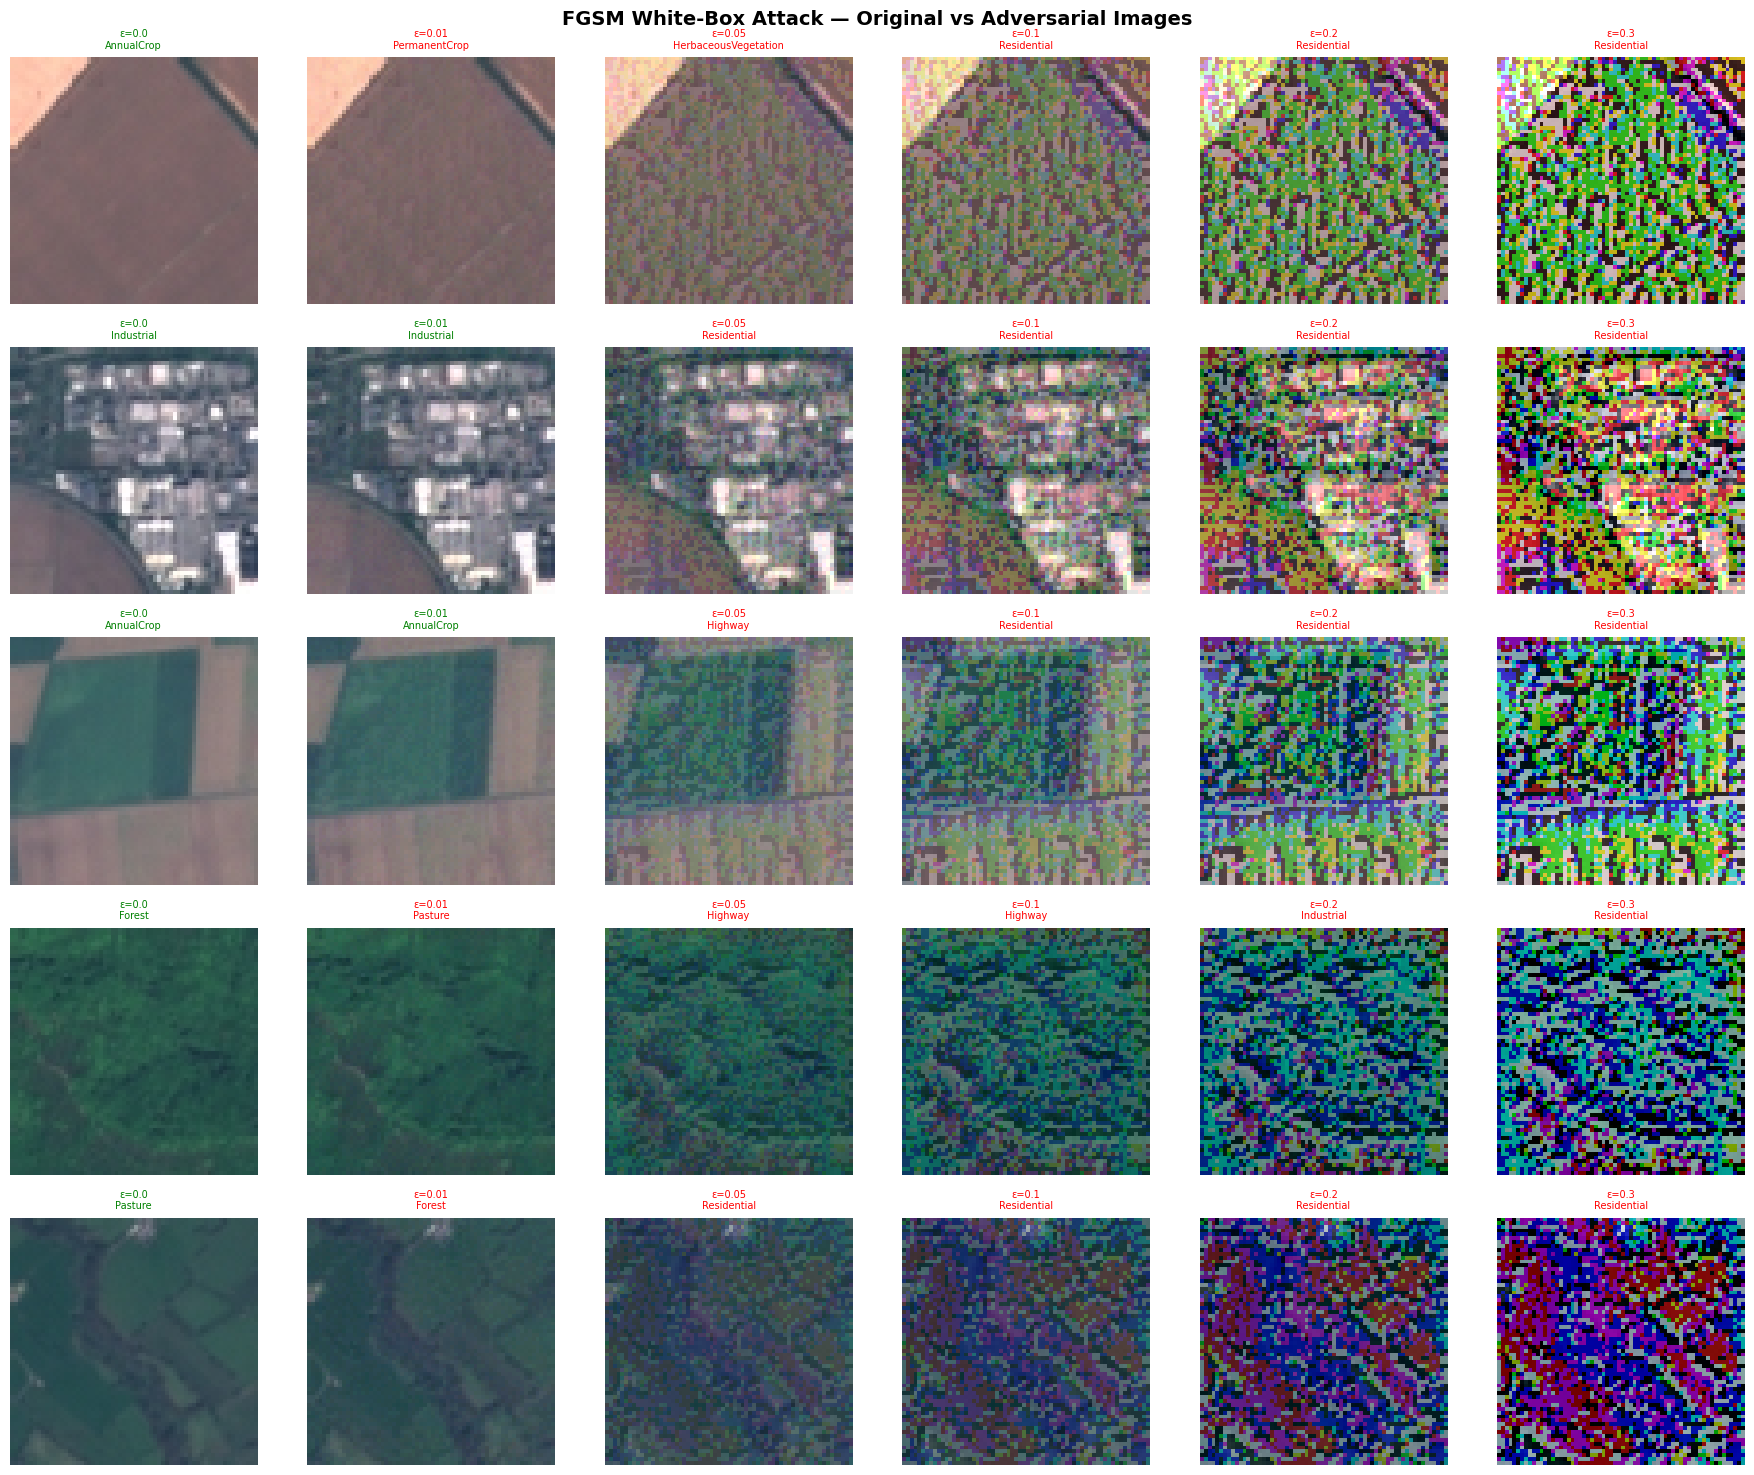

✅ FGSM visualization saved!


In [12]:
# Visualize FGSM results on sample images
sample_imgs  = test_images[:5]
sample_lbls  = test_labels[:5]

fig, axes = plt.subplots(5, len(epsilons), figsize=(18, 15))
fig.suptitle("FGSM White-Box Attack — Original vs Adversarial Images", fontsize=14, fontweight='bold')

for col, eps in enumerate(epsilons):
    adv_imgs = fgsm_attack(model, sample_imgs, sample_lbls, eps)
    for row in range(5):
        ax  = axes[row][col]
        img = adv_imgs[row].numpy()
        pred = CLASS_NAMES[tf.argmax(model(adv_imgs[row:row+1]), axis=1).numpy()[0]]
        true = CLASS_NAMES[sample_lbls[row].numpy()]
        correct = pred == true
        ax.imshow(img)
        ax.set_title(f"ε={eps}\n{pred}", fontsize=7,
                     color='green' if correct else 'red')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f"True:\n{true}", fontsize=7, rotation=0, labelpad=50, va='center')

plt.tight_layout()
plt.savefig("fgsm_results.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ FGSM visualization saved!")


In [13]:
# Black-Box Attack — Simple Decision-Based Attack
# No gradients, no model internals — only queries output label
print("Running Black-Box Attack (Decision-Based)...")
print("Note: Only queries model output — no gradients used!\n")

def blackbox_attack(model, image, true_label, num_steps=100, step_size=0.05):
    """
    Simple black-box attack — only uses model predicted label.
    Starts from random noise and moves toward original image
    while staying adversarial.
    """
    orig = image.numpy().copy()

    # Step 1: Find a starting point that is already misclassified
    adv = np.random.uniform(0, 1, orig.shape).astype(np.float32)
    for _ in range(1000):
        pred = tf.argmax(model(adv[np.newaxis,...], training=False), axis=1).numpy()[0]
        if pred != true_label:
            break
        adv = np.random.uniform(0, 1, orig.shape).astype(np.float32)

    # Step 2: Walk toward original while staying adversarial
    for step in range(num_steps):
        # Move toward original image
        direction = orig - adv
        candidate = adv + step_size * direction
        candidate = np.clip(candidate, 0, 1).astype(np.float32)

        # Only move if still adversarial (black-box: only check label)
        pred = tf.argmax(model(candidate[np.newaxis,...], training=False), axis=1).numpy()[0]
        if pred != true_label:
            adv = candidate

    final_pred = tf.argmax(model(adv[np.newaxis,...], training=False), axis=1).numpy()[0]
    is_adversarial = final_pred != true_label
    return adv, is_adversarial, final_pred

# Run on sample images
adv_images_bb = []
is_adv_list   = []
adv_preds     = []

for i in range(len(bb_images)):
    adv, is_adv, pred = blackbox_attack(
        model, bb_images[i], bb_labels[i].numpy()
    )
    adv_images_bb.append(adv)
    is_adv_list.append(is_adv)
    adv_preds.append(pred)
    status = "✅ Fooled" if is_adv else "❌ Failed"
    print(f"  Image {i+1}: True={CLASS_NAMES[bb_labels[i].numpy()]:15s} "
          f"Pred={CLASS_NAMES[pred]:15s} {status}")

adv_images_bb = np.array(adv_images_bb)
bb_acc = sum(1 for x in is_adv_list if not x) / len(is_adv_list) * 100
print(f"\n✅ Black-Box Attack complete!")
print(f"   Attack success rate: {sum(is_adv_list)/len(is_adv_list)*100:.1f}%")
print(f"   Model accuracy after attack: {bb_acc:.1f}%")

Running Black-Box Attack (Decision-Based)...
Note: Only queries model output — no gradients used!

  Image 1: True=Highway         Pred=River           ✅ Fooled
  Image 2: True=Forest          Pred=Residential     ✅ Fooled
  Image 3: True=PermanentCrop   Pred=Residential     ✅ Fooled
  Image 4: True=PermanentCrop   Pred=HerbaceousVegetation ✅ Fooled
  Image 5: True=HerbaceousVegetation Pred=Residential     ✅ Fooled

✅ Black-Box Attack complete!
   Attack success rate: 100.0%
   Model accuracy after attack: 0.0%


In [14]:
# Black-Box Attack — Simple Decision-Based Attack
# No gradients, no model internals — only queries output label
print("Running Black-Box Attack (Decision-Based)...")
print("Note: Only queries model output — no gradients used!\n")

def blackbox_attack(model, image, true_label, num_steps=100, step_size=0.05):
    """
    Simple black-box attack — only uses model predicted label.
    Starts from random noise and moves toward original image
    while staying adversarial.
    """
    orig = image.numpy().copy()

    # Step 1: Find a starting point that is already misclassified
    adv = np.random.uniform(0, 1, orig.shape).astype(np.float32)
    for _ in range(1000):
        pred = tf.argmax(model(adv[np.newaxis,...], training=False), axis=1).numpy()[0]
        if pred != true_label:
            break
        adv = np.random.uniform(0, 1, orig.shape).astype(np.float32)

    # Step 2: Walk toward original while staying adversarial
    for step in range(num_steps):
        # Move toward original image
        direction = orig - adv
        candidate = adv + step_size * direction
        candidate = np.clip(candidate, 0, 1).astype(np.float32)

        # Only move if still adversarial (black-box: only check label)
        pred = tf.argmax(model(candidate[np.newaxis,...], training=False), axis=1).numpy()[0]
        if pred != true_label:
            adv = candidate

    final_pred = tf.argmax(model(adv[np.newaxis,...], training=False), axis=1).numpy()[0]
    is_adversarial = final_pred != true_label
    return adv, is_adversarial, final_pred

# Run on sample images
adv_images_bb = []
is_adv_list   = []
adv_preds     = []

for i in range(len(bb_images)):
    adv, is_adv, pred = blackbox_attack(
        model, bb_images[i], bb_labels[i].numpy()
    )
    adv_images_bb.append(adv)
    is_adv_list.append(is_adv)
    adv_preds.append(pred)
    status = "✅ Fooled" if is_adv else "❌ Failed"
    print(f"  Image {i+1}: True={CLASS_NAMES[bb_labels[i].numpy()]:15s} "
          f"Pred={CLASS_NAMES[pred]:15s} {status}")

adv_images_bb = np.array(adv_images_bb)
bb_acc = sum(1 for x in is_adv_list if not x) / len(is_adv_list) * 100
print(f"\n✅ Black-Box Attack complete!")
print(f"   Attack success rate: {sum(is_adv_list)/len(is_adv_list)*100:.1f}%")
print(f"   Model accuracy after attack: {bb_acc:.1f}%")

Running Black-Box Attack (Decision-Based)...
Note: Only queries model output — no gradients used!

  Image 1: True=Highway         Pred=HerbaceousVegetation ✅ Fooled
  Image 2: True=Forest          Pred=Residential     ✅ Fooled
  Image 3: True=PermanentCrop   Pred=Residential     ✅ Fooled
  Image 4: True=PermanentCrop   Pred=HerbaceousVegetation ✅ Fooled
  Image 5: True=HerbaceousVegetation Pred=Residential     ✅ Fooled

✅ Black-Box Attack complete!
   Attack success rate: 100.0%
   Model accuracy after attack: 0.0%


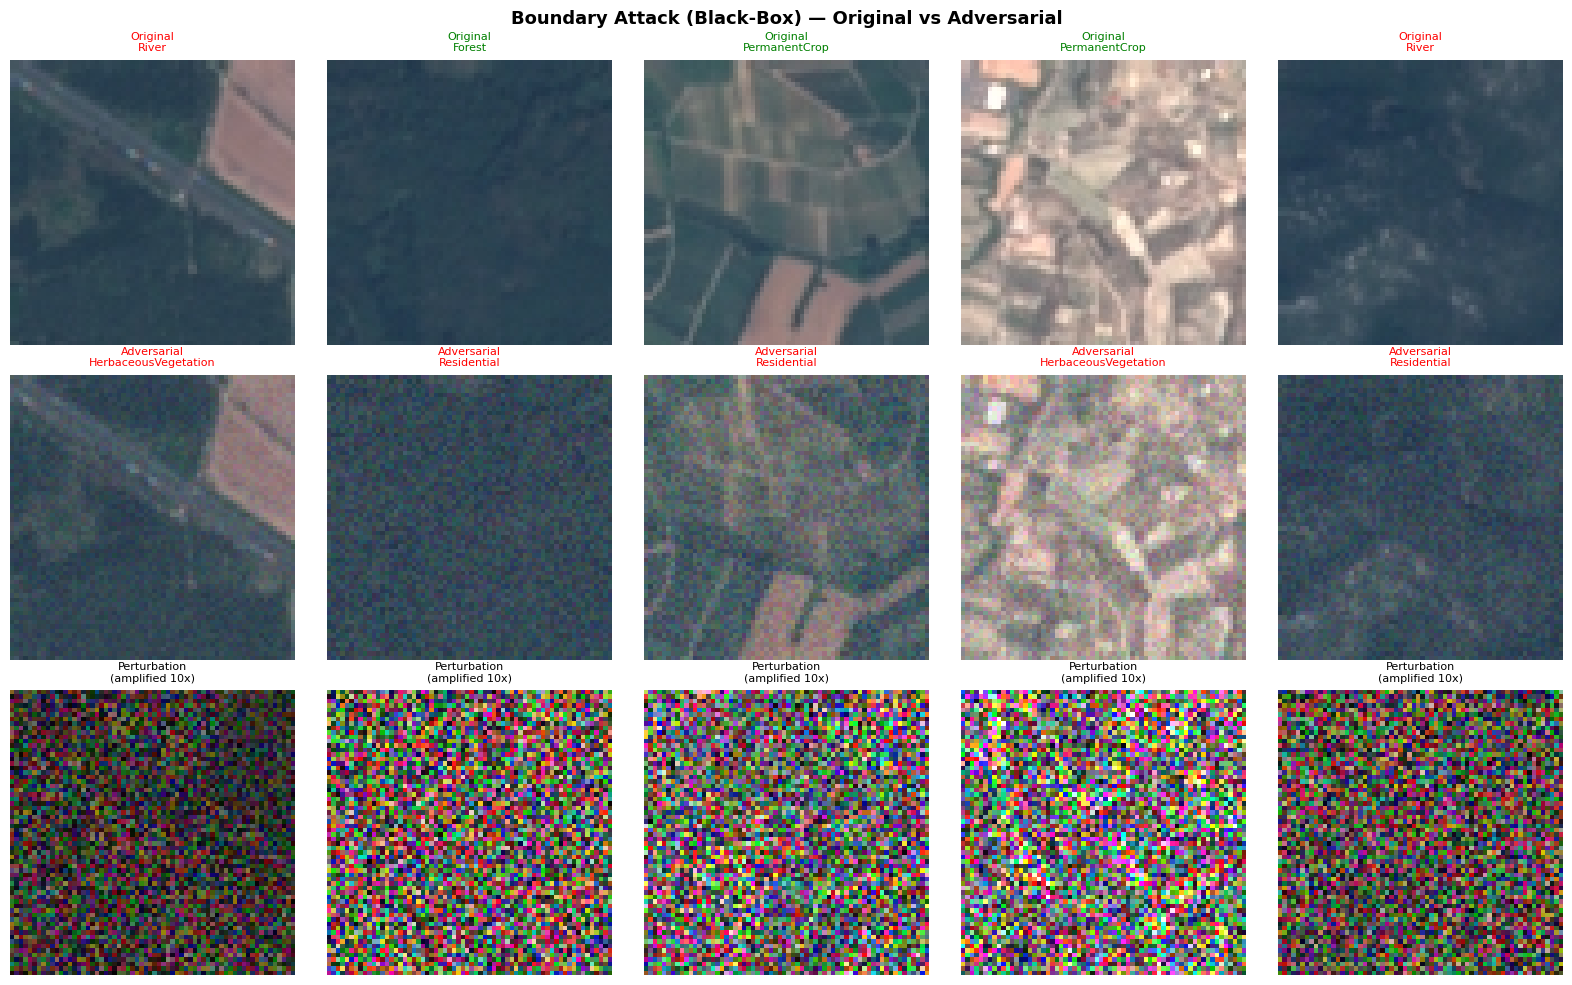

✅ Boundary attack visualization saved!


In [15]:
# Visualize Boundary Attack results
fig, axes = plt.subplots(3, min(5, len(bb_images)), figsize=(16, 10))
fig.suptitle("Boundary Attack (Black-Box) — Original vs Adversarial", fontsize=13, fontweight='bold')

n = min(5, len(bb_images))
for i in range(n):
    orig_img = bb_images[i].numpy()
    adv_img  = adv_images_bb[i]
    diff_img = np.abs(orig_img - adv_img) * 10  # amplify diff for visibility

    true_lbl  = CLASS_NAMES[bb_labels[i].numpy()]
    orig_pred = CLASS_NAMES[tf.argmax(model(bb_images[i:i+1]), 1).numpy()[0]]
    adv_pred  = CLASS_NAMES[tf.argmax(model(adv_img[np.newaxis,...]), 1).numpy()[0]]

    # Row 1: Original
    axes[0][i].imshow(orig_img)
    axes[0][i].set_title(f"Original\n{orig_pred}", fontsize=8,
                          color='green' if orig_pred==true_lbl else 'red')
    axes[0][i].axis('off')

    # Row 2: Adversarial
    axes[1][i].imshow(np.clip(adv_img, 0, 1))
    axes[1][i].set_title(f"Adversarial\n{adv_pred}", fontsize=8,
                          color='green' if adv_pred==true_lbl else 'red')
    axes[1][i].axis('off')

    # Row 3: Difference (amplified)
    axes[2][i].imshow(np.clip(diff_img, 0, 1), cmap='hot')
    axes[2][i].set_title("Perturbation\n(amplified 10x)", fontsize=8)
    axes[2][i].axis('off')

axes[0][0].set_ylabel("Original", fontsize=9, fontweight='bold')
axes[1][0].set_ylabel("Adversarial", fontsize=9, fontweight='bold')
axes[2][0].set_ylabel("Difference", fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("boundary_attack_results.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Boundary attack visualization saved!")


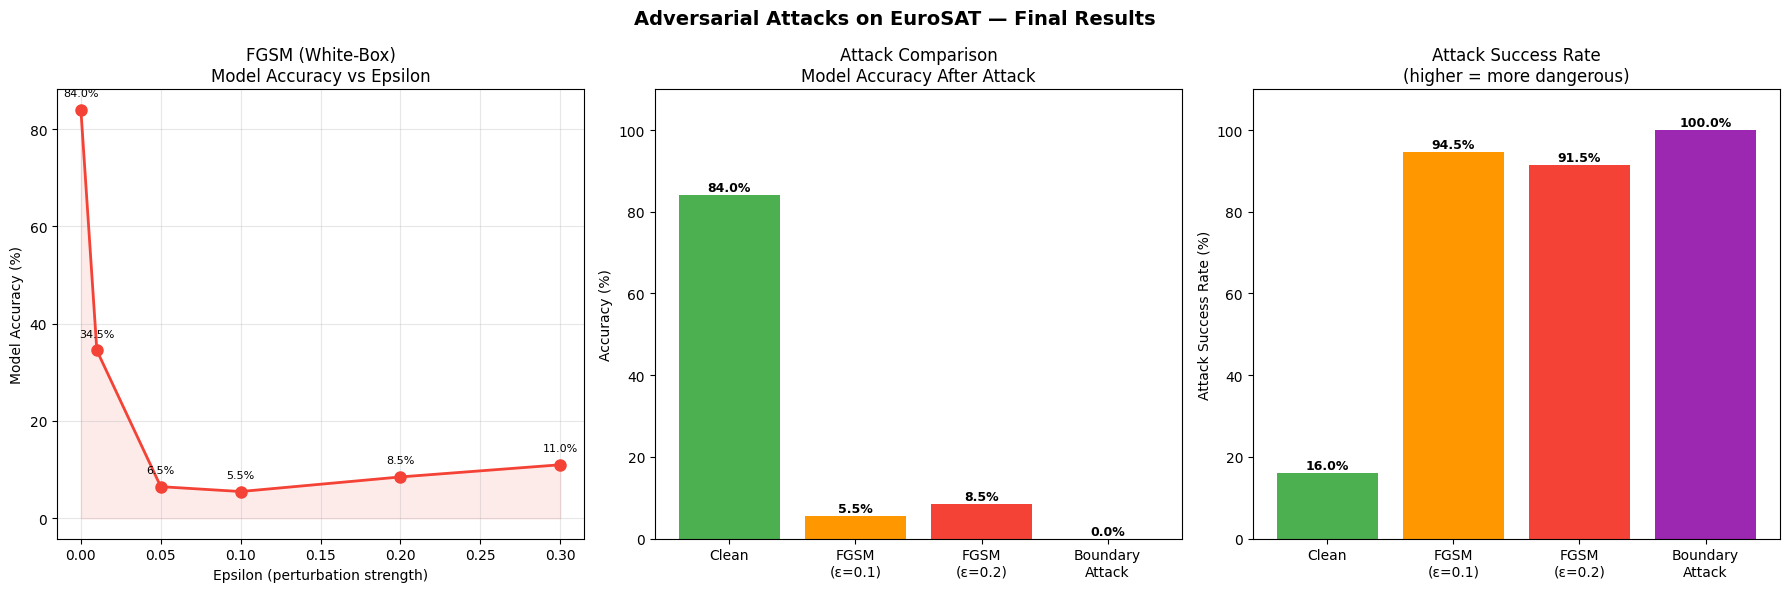

✅ Comparison charts saved!


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Adversarial Attacks on EuroSAT — Final Results", fontsize=14, fontweight='bold')

# 1. FGSM accuracy vs epsilon
axes[0].plot(epsilons, fgsm_accuracies, 'o-', color='#F44336', linewidth=2, markersize=8)
axes[0].fill_between(epsilons, fgsm_accuracies, alpha=0.1, color='#F44336')
axes[0].set_title('FGSM (White-Box)\nModel Accuracy vs Epsilon')
axes[0].set_xlabel('Epsilon (perturbation strength)')
axes[0].set_ylabel('Model Accuracy (%)')
axes[0].grid(True, alpha=0.3)
for x, y in zip(epsilons, fgsm_accuracies):
    axes[0].annotate(f'{y:.1f}%', (x, y), textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=8)

# 2. Attack comparison bar
attack_names   = ['Clean', 'FGSM\n(ε=0.1)', 'FGSM\n(ε=0.2)', 'Boundary\nAttack']
attack_acc     = [fgsm_accuracies[0], fgsm_accuracies[3], fgsm_accuracies[4], bb_acc*100]
bar_colors     = ['#4CAF50', '#FF9800', '#F44336', '#9C27B0']

bars = axes[1].bar(attack_names, attack_acc, color=bar_colors)
axes[1].set_title('Attack Comparison\nModel Accuracy After Attack')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 110)
for bar, val in zip(bars, attack_acc):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

# 3. Attack success rate
success_rates = [100 - a for a in attack_acc]
axes[2].bar(attack_names, success_rates, color=bar_colors)
axes[2].set_title('Attack Success Rate\n(higher = more dangerous)')
axes[2].set_ylabel('Attack Success Rate (%)')
axes[2].set_ylim(0, 110)
for i, val in enumerate(success_rates):
    axes[2].text(i, val+1, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig("attack_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison charts saved!")


New Techniques

In [17]:
# Get test images for all attacks
test_images, test_labels = [], []
for imgs, lbls in test_ds.take(10):
    test_images.append(imgs)
    test_labels.append(lbls)
test_images = tf.concat(test_images, axis=0)[:200]
test_labels = tf.concat(test_labels, axis=0)[:200]

bb_images = test_images[:5]
bb_labels = test_labels[:5]

print(f"✅ Test data ready — {len(test_images)} images loaded")

✅ Test data ready — 200 images loaded


In [18]:
# ═══════════════════════════════════════════════
# PART D — White-Box Attack: PGD
# Stronger version of FGSM — takes multiple steps
# ═══════════════════════════════════════════════

def pgd_attack(model, images, labels, epsilon=0.1, alpha=0.01, num_steps=40):
    """
    Projected Gradient Descent (PGD) Attack.
    Iterative version of FGSM — much stronger.
    alpha = step size per iteration
    num_steps = number of iterations
    """
    images = tf.cast(images, tf.float32)
    labels = tf.cast(labels, tf.int64)

    # Start from random point within epsilon ball
    adv_images = images + tf.random.uniform(images.shape, -epsilon, epsilon)
    adv_images = tf.clip_by_value(adv_images, 0, 1)

    for step in range(num_steps):
        with tf.GradientTape() as tape:
            tape.watch(adv_images)
            predictions = model(adv_images, training=False)
            loss = keras.losses.sparse_categorical_crossentropy(labels, predictions)

        # Take small step in gradient direction
        gradients   = tape.gradient(loss, adv_images)
        adv_images  = adv_images + alpha * tf.sign(gradients)

        # Project back into epsilon ball around original image
        adv_images  = tf.clip_by_value(adv_images, images - epsilon, images + epsilon)
        adv_images  = tf.clip_by_value(adv_images, 0, 1)

    return adv_images

# Test PGD at different epsilon values
epsilons_pgd  = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3]
pgd_accuracies = []

print("Running PGD Attack (40 steps)...\n")
for eps in epsilons_pgd:
    adv_imgs = pgd_attack(model, test_images, test_labels, epsilon=eps)
    preds    = model(adv_imgs, training=False)
    acc      = tf.reduce_mean(
        tf.cast(tf.argmax(preds, axis=1) == tf.cast(test_labels, tf.int64), tf.float32)
    ).numpy()
    pgd_accuracies.append(acc * 100)
    print(f"  Epsilon {eps:.2f} → Accuracy: {acc*100:.1f}%  Attack Success: {100-acc*100:.1f}%")

print("\n✅ PGD Attack complete!")

Running PGD Attack (40 steps)...

  Epsilon 0.00 → Accuracy: 82.5%  Attack Success: 17.5%
  Epsilon 0.01 → Accuracy: 20.5%  Attack Success: 79.5%
  Epsilon 0.05 → Accuracy: 0.0%  Attack Success: 100.0%
  Epsilon 0.10 → Accuracy: 0.0%  Attack Success: 100.0%
  Epsilon 0.20 → Accuracy: 0.0%  Attack Success: 100.0%
  Epsilon 0.30 → Accuracy: 0.0%  Attack Success: 100.0%

✅ PGD Attack complete!


In [19]:
# ═══════════════════════════════════════════════
# PART F — White-Box Attack: UAP
# Universal Adversarial Perturbation
# One single perturbation that fools ALL images
# ═══════════════════════════════════════════════

def uap_attack(model, images, labels, epsilon=0.1, num_epochs=5):
    """
    Universal Adversarial Perturbation —
    finds ONE perturbation that fools the entire dataset.
    """
    # Start with zero perturbation
    uap = tf.Variable(tf.zeros([1, IMG_SIZE, IMG_SIZE, 3]), dtype=tf.float32)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

    print("  Learning universal perturbation...")
    for epoch in range(num_epochs):
        total_loss = 0
        for i in range(0, len(images), 16):
            batch_imgs = images[i:i+16]
            batch_lbls = labels[i:i+16]

            with tf.GradientTape() as tape:
                # Add universal perturbation to all images
                perturbed = tf.clip_by_value(batch_imgs + uap, 0, 1)
                preds     = model(perturbed, training=False)
                # Maximize loss = fool the model
                loss = -tf.reduce_mean(
                    keras.losses.sparse_categorical_crossentropy(
                        tf.cast(batch_lbls, tf.int64), preds
                    )
                )

            grads = tape.gradient(loss, uap)
            optimizer.apply_gradients([(grads, uap)])

            # Clip UAP to epsilon ball
            uap.assign(tf.clip_by_value(uap, -epsilon, epsilon))
            total_loss += loss.numpy()

        # Evaluate current UAP
        perturbed_all = tf.clip_by_value(images + uap, 0, 1)
        preds_all     = model(perturbed_all, training=False)
        acc = tf.reduce_mean(
            tf.cast(tf.argmax(preds_all,1) == tf.cast(labels, tf.int64), tf.float32)
        ).numpy()
        print(f"  Epoch {epoch+1}/{num_epochs} — Accuracy under UAP: {acc*100:.1f}%  Attack Success: {100-acc*100:.1f}%")

    return uap.numpy()[0]

# Run UAP
print("Running UAP Attack...")
print("Learning ONE perturbation to fool ALL images...\n")

uap_pert = uap_attack(model, test_images, test_labels, epsilon=0.1, num_epochs=5)

# Evaluate final UAP
perturbed = tf.clip_by_value(test_images + uap_pert[np.newaxis,...], 0, 1)
preds     = model(perturbed, training=False)
uap_acc   = tf.reduce_mean(
    tf.cast(tf.argmax(preds,1) == tf.cast(test_labels, tf.int64), tf.float32)
).numpy() * 100

print(f"\n✅ UAP complete!")
print(f"   Clean accuracy       : {fgsm_accuracies[0]:.1f}%")
print(f"   Accuracy under UAP   : {uap_acc:.1f}%")
print(f"   Attack success rate  : {100-uap_acc:.1f}%")
print(f"   Perturbation epsilon : 0.1")
print(f"   UAP norm (L2)        : {np.linalg.norm(uap_pert):.4f}")

Running UAP Attack...
Learning ONE perturbation to fool ALL images...

  Learning universal perturbation...
  Epoch 1/5 — Accuracy under UAP: 17.5%  Attack Success: 82.5%
  Epoch 2/5 — Accuracy under UAP: 14.5%  Attack Success: 85.5%
  Epoch 3/5 — Accuracy under UAP: 14.5%  Attack Success: 85.5%
  Epoch 4/5 — Accuracy under UAP: 14.5%  Attack Success: 85.5%
  Epoch 5/5 — Accuracy under UAP: 14.0%  Attack Success: 86.0%

✅ UAP complete!
   Clean accuracy       : 84.0%
   Accuracy under UAP   : 14.0%
   Attack success rate  : 86.0%
   Perturbation epsilon : 0.1
   UAP norm (L2)        : 10.5591


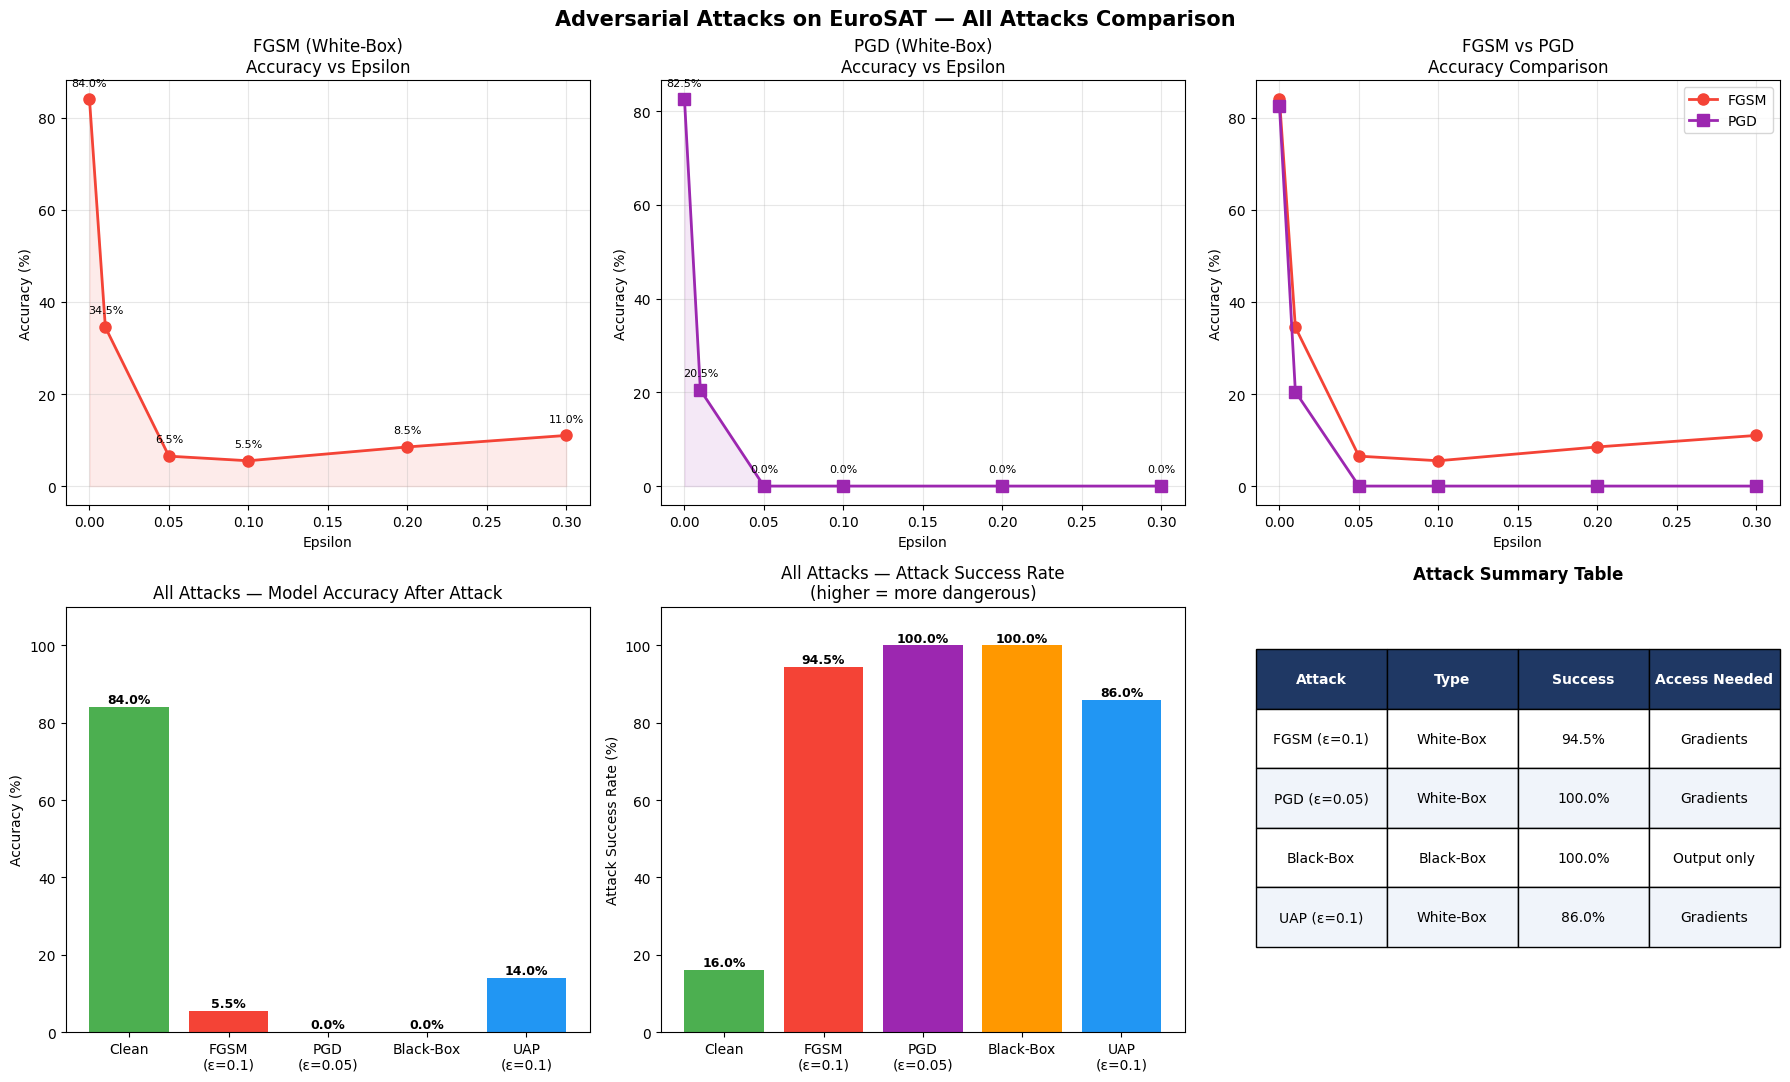

✅ Final comparison chart saved!

🎯 ALL ATTACKS COMPLETE!
   FGSM (ε=0.1)  → Success: 94.5%
   PGD  (ε=0.05) → Success: 100.0%
   Black-Box      → Success: 100.0%
   UAP  (ε=0.1)  → Success: 86.0%


In [20]:
# ═══════════════════════════════════════════════
# PART G — Final Comparison of ALL Attacks
# ═══════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Adversarial Attacks on EuroSAT — All Attacks Comparison",
             fontsize=15, fontweight='bold')

# ── 1. FGSM accuracy vs epsilon ──
ax = axes[0,0]
ax.plot(epsilons, fgsm_accuracies, 'o-', color='#F44336', linewidth=2, markersize=8)
ax.fill_between(epsilons, fgsm_accuracies, alpha=0.1, color='#F44336')
ax.set_title('FGSM (White-Box)\nAccuracy vs Epsilon')
ax.set_xlabel('Epsilon'); ax.set_ylabel('Accuracy (%)')
ax.grid(True, alpha=0.3)
for x, y in zip(epsilons, fgsm_accuracies):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=8)

# ── 2. PGD accuracy vs epsilon ──
ax = axes[0,1]
ax.plot(epsilons_pgd, pgd_accuracies, 's-', color='#9C27B0', linewidth=2, markersize=8)
ax.fill_between(epsilons_pgd, pgd_accuracies, alpha=0.1, color='#9C27B0')
ax.set_title('PGD (White-Box)\nAccuracy vs Epsilon')
ax.set_xlabel('Epsilon'); ax.set_ylabel('Accuracy (%)')
ax.grid(True, alpha=0.3)
for x, y in zip(epsilons_pgd, pgd_accuracies):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=8)

# ── 3. FGSM vs PGD comparison ──
ax = axes[0,2]
ax.plot(epsilons, fgsm_accuracies, 'o-', color='#F44336', linewidth=2,
        markersize=8, label='FGSM')
ax.plot(epsilons_pgd, pgd_accuracies, 's-', color='#9C27B0', linewidth=2,
        markersize=8, label='PGD')
ax.set_title('FGSM vs PGD\nAccuracy Comparison')
ax.set_xlabel('Epsilon'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(True, alpha=0.3)

# ── 4. All attacks bar chart ──
ax = axes[1,0]
attack_names = ['Clean', 'FGSM\n(ε=0.1)', 'PGD\n(ε=0.05)',
                'Black-Box', 'UAP\n(ε=0.1)']
attack_accs  = [
    fgsm_accuracies[0],
    fgsm_accuracies[3],
    pgd_accuracies[2],
    bb_acc * 100 if isinstance(bb_acc, float) and bb_acc <= 1 else bb_acc,
    uap_acc
]
colors = ['#4CAF50', '#F44336', '#9C27B0', '#FF9800', '#2196F3']
bars   = ax.bar(attack_names, attack_accs, color=colors)
ax.set_title('All Attacks — Model Accuracy After Attack')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 110)
for bar, val in zip(bars, attack_accs):
    ax.text(bar.get_x()+bar.get_width()/2, val+1,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

# ── 5. Attack success rate ──
ax = axes[1,1]
success_rates = [100 - a for a in attack_accs]
bars = ax.bar(attack_names, success_rates, color=colors)
ax.set_title('All Attacks — Attack Success Rate\n(higher = more dangerous)')
ax.set_ylabel('Attack Success Rate (%)')
ax.set_ylim(0, 110)
for bar, val in zip(bars, success_rates):
    ax.text(bar.get_x()+bar.get_width()/2, val+1,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

# ── 6. Attack summary table ──
ax = axes[1,2]
ax.axis('off')
table_data = [
    ['Attack',       'Type',       'Success', 'Access Needed'],
    ['FGSM (ε=0.1)', 'White-Box',  f"{100-fgsm_accuracies[3]:.1f}%", 'Gradients'],
    ['PGD (ε=0.05)', 'White-Box',  f"{100-pgd_accuracies[2]:.1f}%",  'Gradients'],
    ['Black-Box',    'Black-Box',  f"{(1-bb_acc)*100 if bb_acc<=1 else 100-bb_acc:.1f}%", 'Output only'],
    ['UAP (ε=0.1)',  'White-Box',  f"{100-uap_acc:.1f}%",            'Gradients'],
]
table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                 cellLoc='center', loc='center',
                 bbox=[0, 0.2, 1, 0.7])
table.auto_set_font_size(False)
table.set_fontsize(10)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1F3864')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F0F4FA')
ax.set_title('Attack Summary Table', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig("all_attacks_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final comparison chart saved!")
print("\n🎯 ALL ATTACKS COMPLETE!")
print(f"   FGSM (ε=0.1)  → Success: {100-fgsm_accuracies[3]:.1f}%")
print(f"   PGD  (ε=0.05) → Success: {100-pgd_accuracies[2]:.1f}%")
print(f"   Black-Box      → Success: {(1-bb_acc)*100 if bb_acc<=1 else 100-bb_acc:.1f}%")
print(f"   UAP  (ε=0.1)  → Success: {100-uap_acc:.1f}%")

Creating Flask **API** **bold text**

In [21]:
!pip install pyngrok -q
from pyngrok import ngrok
import base64, io
from PIL import Image
print("✅ Ready!")

✅ Ready!


In [22]:
from flask import Flask, request, jsonify
import threading, datetime
import numpy as np
import tensorflow as tf

app = Flask(__name__)

# Load model
adv_model = tf.keras.models.load_model("eurosat_model.keras")

CLASS_NAMES_API = CLASS_NAMES  # from your notebook

def decode_image(b64_string):
    """Convert base64 image string to numpy array."""
    img_bytes = base64.b64decode(b64_string)
    img       = Image.open(io.BytesIO(img_bytes)).resize((64, 64))
    img_array = np.array(img).astype(np.float32) / 255.0
    return img_array

def encode_image(img_array):
    """Convert numpy array back to base64 string."""
    img_uint8 = (np.clip(img_array, 0, 1) * 255).astype(np.uint8)
    img_pil   = Image.fromarray(img_uint8)
    buffer    = io.BytesIO()
    img_pil.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode()

# ── Route 1: Home ──
@app.route("/", methods=["GET"])
def home():
    return jsonify({
        "status":  "running",
        "api":     "Adversarial Attack API — EuroSAT",
        "model":   "CNN trained on EuroSAT (10 classes)",
        "endpoints": {
            "GET  /":        "API status",
            "POST /predict": "Predict class of image",
            "POST /fgsm":    "Apply FGSM attack on image",
            "POST /pgd":     "Apply PGD attack on image",
            "POST /uap":     "Apply UAP attack on image",
            "POST /compare": "Compare all attacks on one image"
        }
    })

# ── Route 2: /predict ──
@app.route("/predict", methods=["POST"])
def predict():
    data    = request.get_json()
    img     = decode_image(data["image"])
    pred    = adv_model(tf.constant(img[np.newaxis,...]), training=False)[0].numpy()
    label   = CLASS_NAMES_API[np.argmax(pred)]
    conf    = float(np.max(pred))
    return jsonify({
        "predicted_class": label,
        "confidence":      round(conf, 4),
        "all_probs":       {CLASS_NAMES_API[i]: round(float(pred[i]), 4) for i in range(len(CLASS_NAMES_API))}
    })

# ── Route 3: /fgsm ──
@app.route("/fgsm", methods=["POST"])
def fgsm():
    data      = request.get_json()
    img       = decode_image(data["image"])
    epsilon   = float(data.get("epsilon", 0.1))
    img_tf    = tf.constant(img[np.newaxis,...], dtype=tf.float32)

    # Get original prediction
    orig_pred  = adv_model(img_tf, training=False)[0].numpy()
    orig_label = CLASS_NAMES_API[np.argmax(orig_pred)]
    orig_label_idx = np.argmax(orig_pred)

    # FGSM attack
    img_var = tf.Variable(img_tf)
    with tf.GradientTape() as tape:
        tape.watch(img_var)
        pred = adv_model(img_var, training=False)
        loss = keras.losses.sparse_categorical_crossentropy(
            tf.constant([orig_label_idx]), pred
        )
    grad    = tape.gradient(loss, img_var)
    adv_img = tf.clip_by_value(img_var + epsilon * tf.sign(grad), 0, 1).numpy()[0]

    # Adversarial prediction
    adv_pred  = adv_model(tf.constant(adv_img[np.newaxis,...]), training=False)[0].numpy()
    adv_label = CLASS_NAMES_API[np.argmax(adv_pred)]
    success   = adv_label != orig_label

    return jsonify({
        "attack":              "FGSM",
        "epsilon":             epsilon,
        "original_class":      orig_label,
        "adversarial_class":   adv_label,
        "attack_success":      success,
        "original_confidence": round(float(np.max(orig_pred)), 4),
        "adv_confidence":      round(float(np.max(adv_pred)), 4),
        "adversarial_image":   encode_image(adv_img)
    })

# ── Route 4: /pgd ──
@app.route("/pgd", methods=["POST"])
def pgd():
    data      = request.get_json()
    img       = decode_image(data["image"])
    epsilon   = float(data.get("epsilon", 0.1))
    alpha     = float(data.get("alpha", 0.01))
    steps     = int(data.get("steps", 40))
    img_tf    = tf.constant(img[np.newaxis,...], dtype=tf.float32)

    orig_pred  = adv_model(img_tf, training=False)[0].numpy()
    orig_label = CLASS_NAMES_API[np.argmax(orig_pred)]

    # PGD attack
    adv_imgs = pgd_attack(adv_model,
                          tf.constant(img[np.newaxis,...]),
                          tf.constant([np.argmax(orig_pred)]),
                          epsilon=epsilon, alpha=alpha, num_steps=steps)
    adv_img   = adv_imgs.numpy()[0]
    adv_pred  = adv_model(tf.constant(adv_img[np.newaxis,...]), training=False)[0].numpy()
    adv_label = CLASS_NAMES_API[np.argmax(adv_pred)]

    return jsonify({
        "attack":            "PGD",
        "epsilon":           epsilon,
        "steps":             steps,
        "original_class":    orig_label,
        "adversarial_class": adv_label,
        "attack_success":    adv_label != orig_label,
        "adversarial_image": encode_image(adv_img)
    })

# ── Route 5: /uap ──
@app.route("/uap", methods=["POST"])
def uap():
    data      = request.get_json()
    img       = decode_image(data["image"])
    img_tf    = tf.constant(img[np.newaxis,...], dtype=tf.float32)

    orig_pred  = adv_model(img_tf, training=False)[0].numpy()
    orig_label = CLASS_NAMES_API[np.argmax(orig_pred)]

    # Apply pre-computed UAP
    adv_img   = np.clip(img + uap_pert, 0, 1).astype(np.float32)
    adv_pred  = adv_model(tf.constant(adv_img[np.newaxis,...]), training=False)[0].numpy()
    adv_label = CLASS_NAMES_API[np.argmax(adv_pred)]

    return jsonify({
        "attack":            "UAP",
        "original_class":    orig_label,
        "adversarial_class": adv_label,
        "attack_success":    adv_label != orig_label,
        "uap_norm":          round(float(np.linalg.norm(uap_pert)), 4),
        "adversarial_image": encode_image(adv_img)
    })

# ── Route 6: /compare — all attacks on one image ──
@app.route("/compare", methods=["POST"])
def compare():
    data      = request.get_json()
    img       = decode_image(data["image"])
    epsilon   = float(data.get("epsilon", 0.1))
    img_tf    = tf.constant(img[np.newaxis,...], dtype=tf.float32)

    orig_pred  = adv_model(img_tf, training=False)[0].numpy()
    orig_label = CLASS_NAMES_API[np.argmax(orig_pred)]
    orig_idx   = np.argmax(orig_pred)

    results = {"original_class": orig_label, "epsilon": epsilon, "attacks": {}}

    # FGSM
    img_var = tf.Variable(img_tf)
    with tf.GradientTape() as tape:
        tape.watch(img_var)
        pred = adv_model(img_var, training=False)
        loss = keras.losses.sparse_categorical_crossentropy(tf.constant([orig_idx]), pred)
    grad      = tape.gradient(loss, img_var)
    fgsm_img  = tf.clip_by_value(img_var + epsilon * tf.sign(grad), 0, 1).numpy()[0]
    fgsm_pred = CLASS_NAMES_API[np.argmax(adv_model(tf.constant(fgsm_img[np.newaxis,...]), training=False)[0].numpy())]
    results["attacks"]["FGSM"] = {"predicted": fgsm_pred, "success": fgsm_pred != orig_label}

    # PGD
    pgd_img   = pgd_attack(adv_model, tf.constant(img[np.newaxis,...]),
                           tf.constant([orig_idx]), epsilon=epsilon).numpy()[0]
    pgd_pred  = CLASS_NAMES_API[np.argmax(adv_model(tf.constant(pgd_img[np.newaxis,...]), training=False)[0].numpy())]
    results["attacks"]["PGD"]  = {"predicted": pgd_pred,  "success": pgd_pred != orig_label}

    # UAP
    uap_img   = np.clip(img + uap_pert, 0, 1).astype(np.float32)
    uap_pred  = CLASS_NAMES_API[np.argmax(adv_model(tf.constant(uap_img[np.newaxis,...]), training=False)[0].numpy())]
    results["attacks"]["UAP"]  = {"predicted": uap_pred,  "success": uap_pred != orig_label}

    results["timestamp"] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    return jsonify(results)

print("✅ Flask Adversarial API routes defined!")
print("   GET  /         → API status")
print("   POST /predict  → Predict image class")
print("   POST /fgsm     → FGSM attack")
print("   POST /pgd      → PGD attack")
print("   POST /uap      → UAP attack")
print("   POST /compare  → Compare all attacks")

✅ Flask Adversarial API routes defined!
   GET  /         → API status
   POST /predict  → Predict image class
   POST /fgsm     → FGSM attack
   POST /pgd      → PGD attack
   POST /uap      → UAP attack
   POST /compare  → Compare all attacks


In [25]:
NGROK_TOKEN = "3FTd8Xle8HYi1Yh4Zr9ja3pJorY_3mk8Li5F5qptp5mCKQSHU"
ngrok.set_auth_token(NGROK_TOKEN)

def run_flask():
    app.run(port=5000, use_reloader=False, debug=False)

thread = threading.Thread(target=run_flask)
thread.daemon = True
thread.start()

public_url = ngrok.connect(5000)
print("="*55)
print("✅ Adversarial Attack API is LIVE!")
print(f"   URL      : {public_url}")
print(f"   Predict  : {public_url}/predict")
print(f"   FGSM     : {public_url}/fgsm")
print(f"   PGD      : {public_url}/pgd")
print(f"   UAP      : {public_url}/uap")
print(f"   Compare  : {public_url}/compare")
print("="*55)

 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


✅ Adversarial Attack API is LIVE!
   URL      : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"
   Predict  : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/predict
   FGSM     : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/fgsm
   PGD      : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/pgd
   UAP      : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/uap
   Compare  : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/compare


In [26]:
import requests, json, base64

# Convert a test image to base64
sample_img  = bb_images[0].numpy()
img_uint8   = (sample_img * 255).astype(np.uint8)
img_pil     = Image.fromarray(img_uint8)
buffer      = io.BytesIO()
img_pil.save(buffer, format="PNG")
img_b64     = base64.b64encode(buffer.getvalue()).decode()

# Test 1: Predict
print("TEST 1: /predict")
print("-"*45)
res = requests.post("http://localhost:5000/predict", json={"image": img_b64})
print(json.dumps(res.json(), indent=2))

# Test 2: FGSM
print("\nTEST 2: /fgsm")
print("-"*45)
res = requests.post("http://localhost:5000/fgsm",
                    json={"image": img_b64, "epsilon": 0.1})
r   = res.json()
print(f"  Original  : {r['original_class']}")
print(f"  After FGSM: {r['adversarial_class']}")
print(f"  Success   : {r['attack_success']}")

# Test 3: Compare all
print("\nTEST 3: /compare — all attacks")
print("-"*45)
res = requests.post("http://localhost:5000/compare",
                    json={"image": img_b64, "epsilon": 0.1})
print(json.dumps(res.json(), indent=2))

INFO:werkzeug:127.0.0.1 - - [02/Jul/2026 15:34:42] "POST /predict HTTP/1.1" 200 -


TEST 1: /predict
---------------------------------------------
{
  "all_probs": {
    "AnnualCrop": 0.0007,
    "Forest": 0.992,
    "HerbaceousVegetation": 0.0001,
    "Highway": 0.0,
    "Industrial": 0.0,
    "Pasture": 0.0,
    "PermanentCrop": 0.0,
    "Residential": 0.0,
    "River": 0.0025,
    "SeaLake": 0.0047,
    "label_map.json": 0.0,
    "test.csv": 0.0,
    "train.csv": 0.0,
    "validation.csv": 0.0
  },
  "confidence": 0.992,
  "predicted_class": "Forest"
}

TEST 2: /fgsm
---------------------------------------------


INFO:werkzeug:127.0.0.1 - - [02/Jul/2026 15:34:43] "POST /fgsm HTTP/1.1" 200 -


  Original  : Forest
  After FGSM: Residential
  Success   : True

TEST 3: /compare — all attacks
---------------------------------------------


INFO:werkzeug:127.0.0.1 - - [02/Jul/2026 15:34:44] "POST /compare HTTP/1.1" 200 -


{
  "attacks": {
    "FGSM": {
      "predicted": "Residential",
      "success": true
    },
    "PGD": {
      "predicted": "Residential",
      "success": true
    },
    "UAP": {
      "predicted": "Residential",
      "success": true
    }
  },
  "epsilon": 0.1,
  "original_class": "Forest",
  "timestamp": "2026-07-02 15:34:44"
}
